#### Import libraries 

In [1]:
import numpy as np

#### Load Parameters 

In [2]:
# Import functions for loading parameters (in parameter loading folder)
from parameter_loading.load_biped_model_parameters import load_biped_model_parameters
from parameter_loading.load_sensory_noise_parameters import load_sensory_noise_parameters
from parameter_loading.load_controller_gain_parameters import load_controller_gain_parameters
from parameter_loading.load_learner_parameters import load_learner_parameters
from parameter_loading.load_protocol_parameters import load_protocol_parameters
from parameter_loading.load_stored_memory_parameters_control_vs_speed import load_stored_memory_parameters_control_vs_speed

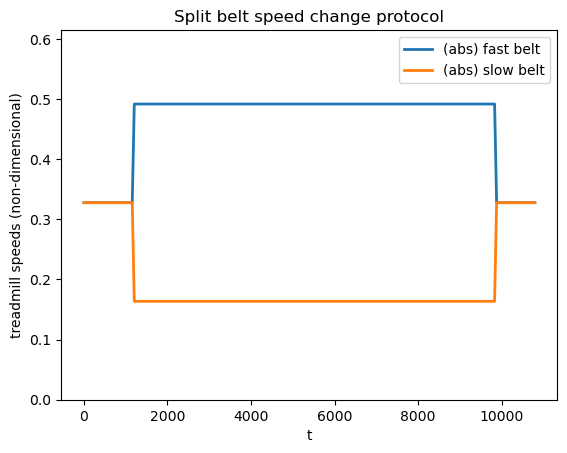

param_fixed parameters:  {'includeAccelerationTorque': 1, 'mbody': 1, 'leglength': 1, 'gravg': 1, 'efficiency_neg': 1.2, 'efficiency_pos': 0.25, 'bPos': 4.0, 'bNeg': 0.8333333333333334, 'mFoot': 0.05, 'swingCost': {'Coeff': 0.9, 'alpha': 1.0}, 'lambdaEnergyVsPeriodicity': 1, 'lambdaEnergyVsSymmetry': 0.75, 'symmetryMultiplier': 10, 'noiseEnergySensory': 0.0001, 'velocitySensoryNoise': 0, 'Learner': {'LearningRate': 0.00012, 'noiseSTDExploratory': 0.002, 'includeInternalModel': 1, 'numStepsToUseForEstimator': 30, 'LearningRateTowardMemory': 0.01, 'powerToTheMoveToMemory': 10, 'powerToTheMemoryFormation': 10, 'LearningRateForMemoryFormationUpdates': 0.03, 'numStepsPerIteration': 2, 'trustRegionSize': 0.0005, 'shouldWeUseTrustRegion': 1, 'predictionErrorThreshold': 0.0002, 'shouldWeThresholdPredictionError': 0, 'alphaForgettingForEstimator': 0}, 'SplitOrTied': 'split', 'speedProtocol': 'classic split belt', 'transitionTime': 15, 'imposedFootSpeeds': {'tList': array([    0.        ,   192.

In [3]:
# Initialize parameters
param_fixed = {}
np.random.seed() 

# Load parameters 
param_fixed = load_biped_model_parameters(param_fixed)
param_fixed = load_sensory_noise_parameters(param_fixed)
param_controller_gains = load_controller_gain_parameters(param_fixed)
param_fixed = load_learner_parameters(param_fixed)
param_fixed = load_protocol_parameters(param_fixed)
param_fixed = load_stored_memory_parameters_control_vs_speed(param_fixed)

# Print parameters
print("param_fixed parameters: ", param_fixed)
print("param_controller_gains parameters: ", param_controller_gains)



#### Initialize Body Parameters

In [4]:
from initializing.load_learnable_parameters_initial import load_learnable_parameters_initial
from initializing.load_initial_body_state import load_initial_body_state
from initializing.get_treadmill_speed import get_treadmill_speed

In [5]:
p_input_controller_asymmetric_nominal = load_learnable_parameters_initial(param_fixed)
state_var0_model = load_initial_body_state(p_input_controller_asymmetric_nominal)
t_start = 0
state_var0_model_before_learning = state_var0_model

print("p_input_controller_asymmetric_nominal: ", p_input_controller_asymmetric_nominal)
print("state_var0_model: ", state_var0_model)


p_input_controller_asymmetric_nominal:  [ 3.28221263e-01  3.10751797e-01  1.53556844e-01  0.00000000e+00
  0.00000000e+00  3.28221491e-01  3.10751695e-01  1.53557221e-01
 -3.89537350e-08 -3.89537350e-08]
state_var0_model:  [0.        0.3107518 0.        0.        0.35     ]


In [6]:
vA, vB = get_treadmill_speed(0, param_fixed['imposedFootSpeeds'])
context_now = np.array([vA, vB])
context_length = len(context_now)
context_now

array([-0.3276, -0.3276])

---

### Learning Loop

In [8]:
from learning.simulate_learning_step_by_step import simulate_learning_step_by_step



In [9]:


pInputControllerStore_OnesTried = simulate_learning_step_by_step(param_fixed,p_input_controller_asymmetric_nominal, state_var0_model,context_now,param_controller_gains)
pInputControllerStore_OnesTried

AttributeError: 'dict' object has no attribute 'num_iterations'